                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.544
Method:                 Least Squares   F-statistic:                     10.15
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000283
Time:                        08:37:57   Log-Likelihood:                -58.205
No. Observations:                  24   AIC:                             124.4
Df Residuals:                      20   BIC:                             129.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -16.8839      4.703     -3.590      0.0

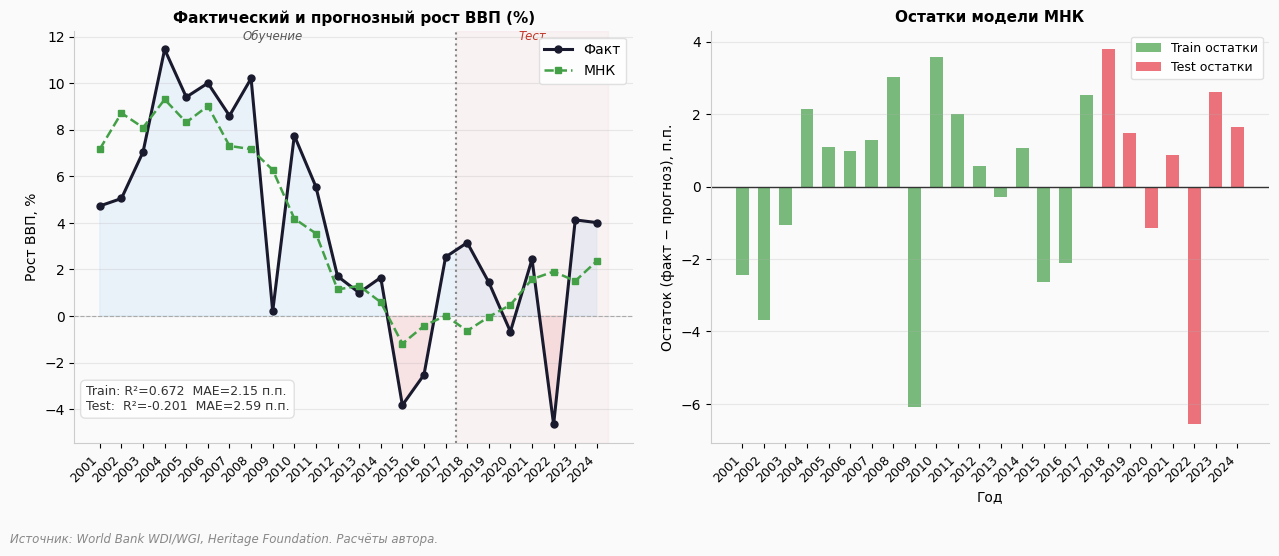

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ── данные ──
df_ml = pd.read_excel('data.xlsx', sheet_name='Data_ML')
df_ml = df_ml.rename(columns={
    'Year': 'year',
    'GDP Growth (%) — TARGET': 'gdp_growth',
    'Lag GDP Growth t-1 (%)': 'lag_gdp',
    'Inflation CPI t-1 (%)': 'inflation',
    'Unemployment t-1 (%)': 'unemployment',
    'Gov. Expenditure t-1 (% GDP)': 'gov_exp',
    'Tax Revenue t-1 (% GDP)': 'tax_rev',
    'Trade Openness t-1 (% GDP)': 'trade_open',
    'FDI Inflows t-1 (% GDP)': 'fdi',
    'WGI Gov. Eff. t-1': 'wgi',
    'Econ. Freedom t-1': 'econ_free',
})
df_ml = df_ml[pd.to_numeric(df_ml['year'], errors='coerce').notna()].copy()
df_ml['year'] = df_ml['year'].astype(int)
for c in df_ml.columns[1:]:
    df_ml[c] = pd.to_numeric(df_ml[c], errors='coerce')

# ── 3 переменных отобранных на EDA ──
cols = ['gov_exp', 'wgi', 'tax_rev']

data  = df_ml[['year','gdp_growth'] + cols].dropna().reset_index(drop=True)
y     = data['gdp_growth'].values.astype(float)
X     = data[cols].values.astype(float)
yrs   = data['year'].values
n     = len(data)

# ── Полная statsmodels модель (на всей выборке — для курсовой) ──
X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()
print(model.summary())

# ── Метрики на всей выборке ──
y_pred_all = model.predict(X_sm)
mae  = mean_absolute_error(y, y_pred_all)
rmse = np.sqrt(mean_squared_error(y, y_pred_all))
r2   = r2_score(y, y_pred_all)
r2adj = model.rsquared_adj
print(f"\nMAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}  R²adj={r2adj:.3f}")

# ── Train/Test split (для сравнения с RF) ──
split = 17  # train 2001–2017, test 2018–2024

X_tr_sm = sm.add_constant(X[:split])
X_te_sm = sm.add_constant(X[split:])

# Важно: добавляем колонку const вручную для тестовой выборки
model_tr = sm.OLS(y[:split], X_tr_sm).fit()
p_te = model_tr.predict(X_te_sm)
p_tr = model_tr.predict(X_tr_sm)

def metrics(yt, yp, label):
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2   = r2_score(yt, yp)
    print(f"{label:22s}  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}")
    return mae, rmse, r2

print("\n=== Train/Test сравнение ===")
tr_m = metrics(y[:split], p_tr, f"Train (2001–{yrs[split-1]})")
te_m = metrics(y[split:],  p_te, f"Test  ({yrs[split]}–{yrs[-1]})")

# ── График ──
plt.rcParams.update({'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})

p_all = np.concatenate([p_tr, p_te])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('#fafafa')

# Левый: факт vs прогноз
ax = axes[0]
ax.set_facecolor('#fafafa')
ax.fill_between(yrs, y, 0, where=(y < 0), alpha=0.12, color='#e63946', interpolate=True)
ax.fill_between(yrs, y, 0, where=(y >= 0), alpha=0.07, color='#2196F3', interpolate=True)
ax.plot(yrs, y,     'o-',  color='#1a1a2e', lw=2.2, ms=5, zorder=3, label='Факт')
ax.plot(yrs, p_all, 's--', color='#43A047', lw=1.8, ms=4, zorder=3, label='МНК')
ax.axvspan(yrs[split] - 0.5, yrs[-1] + 0.5, alpha=0.04, color='#e63946')
ax.axvline(yrs[split] - 0.5, color='#888', ls=':', lw=1.5)
ax.text(yrs[split//2],          y.max() + 0.4, 'Обучение', ha='center',
        fontsize=8.5, color='#555', style='italic')
ax.text(yrs[split + (n-split)//2], y.max() + 0.4, 'Тест', ha='center',
        fontsize=8.5, color='#c0392b', style='italic')
ax.axhline(0, color='#aaa', lw=0.8, ls='--')
ax.set_title('Фактический и прогнозный рост ВВП (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Рост ВВП, %', fontsize=10)
ax.legend(fontsize=10, framealpha=0.9, edgecolor='#ddd', loc='upper right')
ax.set_xticks(yrs)
ax.set_xticklabels(yrs.astype(int), rotation=45, ha='right', fontsize=9)
ax.spines['left'].set_color('#ccc'); ax.spines['bottom'].set_color('#ccc')
ax.grid(axis='y', alpha=0.25)
ax.text(0.02, 0.08,
        f"Train: R²={tr_m[2]:.3f}  MAE={tr_m[0]:.2f} п.п.\n"
        f"Test:  R²={te_m[2]:.3f}  MAE={te_m[0]:.2f} п.п.",
        transform=ax.transAxes, fontsize=9, color='#333',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#ddd', alpha=0.9))

# Правый: остатки (residuals)
resid = y - p_all
ax2 = axes[1]
ax2.set_facecolor('#fafafa')
ax2.bar(yrs[:split], resid[:split], color='#43A047', alpha=0.7,
        label='Train остатки', width=0.6)
ax2.bar(yrs[split:], resid[split:], color='#e63946', alpha=0.7,
        label='Test остатки',  width=0.6)
ax2.axhline(0, color='#333', lw=1.0)
ax2.set_title('Остатки модели МНК', fontsize=11, fontweight='bold')
ax2.set_ylabel('Остаток (факт − прогноз), п.п.', fontsize=10)
ax2.set_xlabel('Год', fontsize=10)
ax2.legend(fontsize=9, framealpha=0.9, edgecolor='#ddd')
ax2.set_xticks(yrs)
ax2.set_xticklabels(yrs.astype(int), rotation=45, ha='right', fontsize=9)
ax2.spines['left'].set_color('#ccc'); ax2.spines['bottom'].set_color('#ccc')
ax2.grid(axis='y', alpha=0.25)

fig.text(0.01, -0.02,
         'Источник: World Bank WDI/WGI, Heritage Foundation. Расчёты автора.',
         fontsize=8.5, color='#888', style='italic')

plt.tight_layout(pad=2.0)
plt.savefig('ols_results.png', dpi=300, bbox_inches='tight', facecolor='#fafafa')
plt.show()